In [52]:
from src.TimeSeriesAnalysis import read_experiment_json, select_random_json, create_folder
from src.stability_tests import *
from src.network_animation import *
import matplotlib.pyplot as plt
import numpy as np
import os
plt.style.use('properties.mplstyle')

In [53]:
results_folder = '../results/stabilization_tests/'
create_folder(results_folder)

In [54]:
def safe_float_or_nan(x):
    try:
        if x is None:
            return np.nan

        value = float(x)

        if not np.isfinite(value):
            return np.nan

        return value

    except (TypeError, ValueError):
        return np.nan


def get_reference_from_group(group, label_series="p_all"):

    orders = group.get("orders", [])

    if label_series == "p_all":

        t_eq_values = []

        for order in orders:
            data = order.get("data", {})
            t_eq_value = safe_float_or_nan(data.get("t_eq"))

            if np.isfinite(t_eq_value):
                t_eq_values.append(t_eq_value)

        if len(t_eq_values) > 0:
            t_eq = max(t_eq_values)
        else:
            t_eq = np.nan

        pc_sop_mean = np.nan

        if "pc_sop" in group and "mean" in group["pc_sop"]:
            pc_sop_mean = safe_float_or_nan(group["pc_sop"]["mean"])

        if not np.isfinite(pc_sop_mean):

            pc_sop_values = []

            for order in orders:
                data = order.get("data", {})
                pc_sop_data = data.get("pc_sop", {})

                pc_sop_value = safe_float_or_nan(pc_sop_data.get("mean"))

                if np.isfinite(pc_sop_value):
                    pc_sop_values.append(pc_sop_value)

            if len(pc_sop_values) > 0:
                pc_sop_mean = np.mean(pc_sop_values)
            else:
                pc_sop_mean = np.nan

    else:

        order = next(
            order for order in orders
            if order.get("label") == label_series
        )

        data = order.get("data", {})

        t_eq = safe_float_or_nan(data.get("t_eq"))

        pc_sop_data = data.get("pc_sop", {})
        pc_sop_mean = safe_float_or_nan(pc_sop_data.get("mean"))

    return t_eq, pc_sop_mean

# $Dim = 3$

<>:177: SyntaxWarning: invalid escape sequence '\m'
<>:177: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4719/3292120017.py:177: SyntaxWarning: invalid escape sequence '\m'
  ax_pt.set_ylabel(f'$\\langle p(t) \\rangle_{{\mathrm{{samples}}}}$', fontsize=fs_label)


s_ = 25, ft = 0.02591667
s_ = 33, ft = 0.02591667
s_ = 45, ft = 0.02591667
s_ = 46, ft = 0.02591667
s_ = 47, ft = 0.02591667
s_ = 52, ft = 0.02591667
s_ = 56, ft = 0.02591667
s_ = 57, ft = 0.02591667
s_ = 61, ft = 0.02591667
s_ = 64, ft = 0.02591667
s_ = 66, ft = 0.02591667
s_ = 67, ft = 0.02591667
s_ = 70, ft = 0.02591667
s_ = 71, ft = 0.02591667
s_ = 77, ft = 0.02591667
s_ = 83, ft = 0.02591667
s_ = 98, ft = 0.02591667
s_ = 104, ft = 0.02591667
s_ = 107, ft = 0.02591667
s_ = 110, ft = 0.02591667
s_ = 113, ft = 0.02591667
s_ = 117, ft = 0.02591667
s_ = 118, ft = 0.02591667
s_ = 119, ft = 0.02591667
s_ = 121, ft = 0.02591667
s_ = 125, ft = 0.02591667
s_ = 127, ft = 0.02591667
s_ = 141, ft = 0.02591667
s_ = 153, ft = 0.02591667
s_ = 155, ft = 0.02591667
s_ = 164, ft = 0.02591667
s_ = 168, ft = 0.02591667
s_ = 174, ft = 0.02591667
s_ = 184, ft = 0.02591667
s_ = 190, ft = 0.02591667
s_ = 191, ft = 0.02591667
s_ = 194, ft = 0.02591667
s_ = 202, ft = 0.02591667
s_ = 204, ft = 0.02591667
s_ 

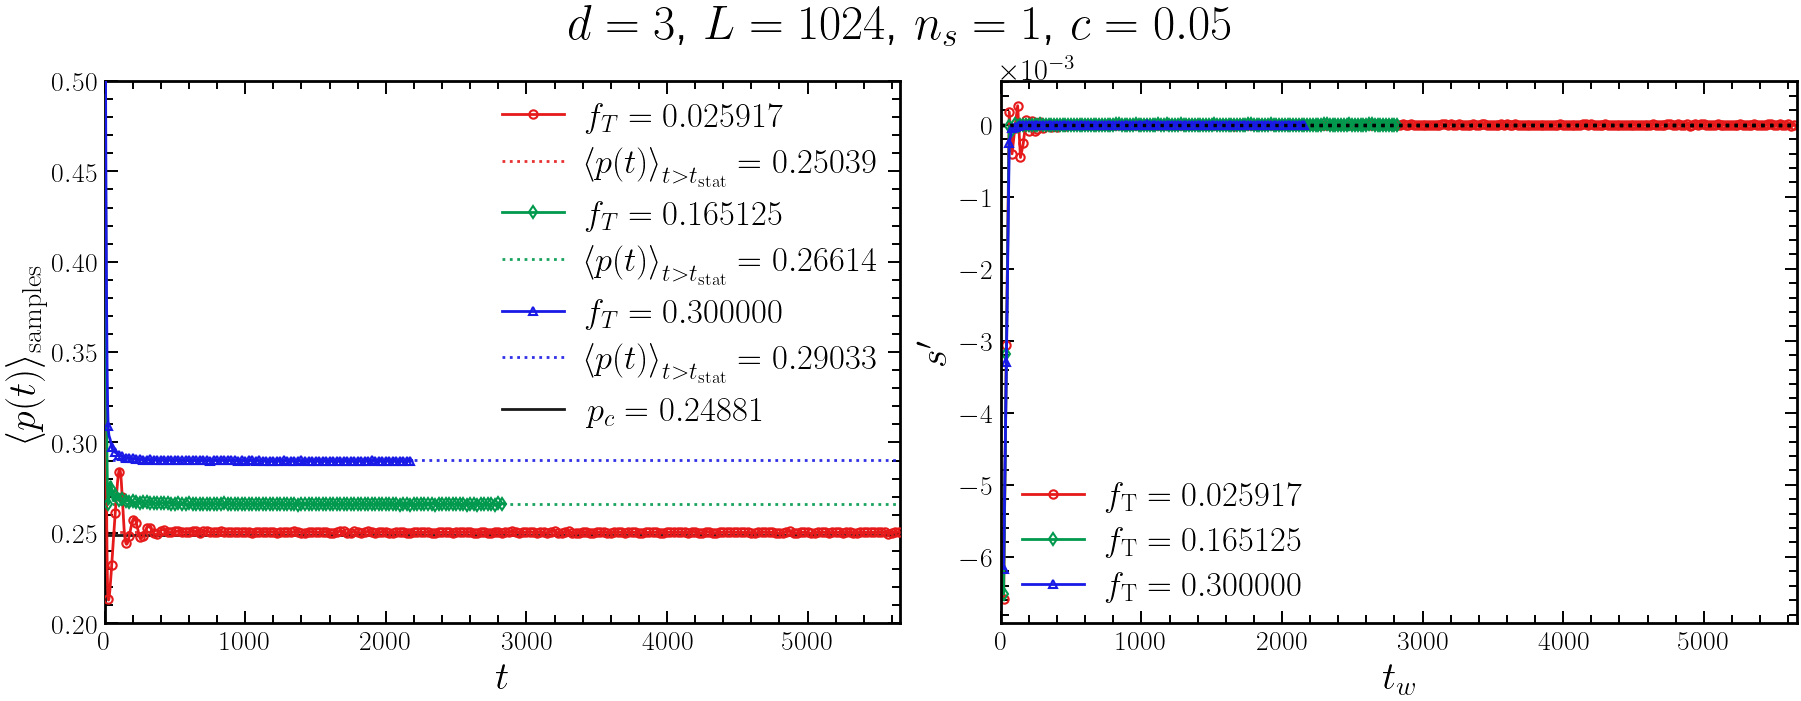

In [ ]:
type_perc = 'bond'
ns = 1
dim = 3
L = 1024

fT_lst = [0.02591667, 0.165125, 0.3]

c = 0.05
rho = 1 / ns

P0_target = 0.10
p0_target = 0.60

label_series = "p_all"   # ou "order_0"

markers = ['o-', 'd-', '^-']

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7),
    constrained_layout=True
)

ax_pt = axes[0]
ax_sp = axes[1]

t_max_pt = 0
t_max_sp = 0

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]
ms = 6
t_max = 0
fs_legend = 25
mew = 1.5
lw = 2.0
pc = 0.24881182
fs_label = 29


for idx, fT in enumerate(fT_lst):
    path = (
        f"../SOP_data/published/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/"
    )

    fn = "properties_mean_bundle.json"

    try:
        bundle = load_properties_bundle(path + fn)

        group = get_group_by_p0_P0(
            bundle,
            p0_target=p0_target,
            P0_target=P0_target
        )

        df_pt_all, results = analyze_pt_group(
            group,
            window_roll=15,
            window_block=20,
            y_key="pt_mean",
            use_rolling_for_blocks=True,
            center=True,
            drop_last=True,
        )
        df_pt = results[label_series]["df_pt"]
        df_s  = results[label_series]["df_s"]

        t_eq, pc_sop_mean = get_reference_from_group(
            group,
            label_series=label_series
        )

        # -----------------------------
        # Painel esquerdo: p(t)
        # -----------------------------
        t_pt = df_pt["t"].to_numpy()
        pt = df_pt["pt"].to_numpy()
        pt_roll = df_pt["pt_roll"].to_numpy()
        
        t_max = max(t_max, max(t_pt))
        t_max_pt = max(t_max_pt, np.max(t_pt))

        ax_pt.plot(
            t_pt,
            pt,
            markers[idx],
            color=colors[idx],
            markevery=25,
            lw=2.0,
            mew = mew,
            ms=ms,
            label=rf"$f_T = {fT:.6f}$",
            zorder=6,
            clip_on = True,
        )
        
        label_pt = rf"$f_{{\mathrm{{T}}}} = {fT:.6f}$"
        label_pc_sop = (
            rf"$\left\langle p(t)\right\rangle_"
            rf"{{t>t_{{\mathrm{{stat}}}}}} = {pc_sop_mean:.5f}$"
        )

        # Linha horizontal do pc tradicional
        label_pc = rf"$p_c = {pc:.5f}$"
        
        ax_pt.set_xlim(0, t_max)
        # ax_pt.axvline(
        #     t_eq,
        #     ls="--",
        #     lw=1.4,
        #     alpha=0.8,
        #     color=colors[idx]
        # )
        ax_pt.set_ylim(0.2, 0.5)
        ax_pt.axhline(
            pc_sop_mean,
            ls=":",
            lw=lw,
            alpha=0.9,
            color=colors[idx],
            label=label_pc_sop
        )
        


        # -----------------------------
        # Painel direito: s'(t)
        # -----------------------------
        t_sp = df_s["t_s"].to_numpy()
        s_prime = df_s["s_prime"].to_numpy()

        t_max_sp = max(t_max_sp, np.max(t_sp))

        ax_sp.plot(
            t_sp,
            s_prime,
            markers[idx],
            color=colors[idx],
            lw=2.0,
            ms=ms,
            mew=mew,
            label=rf"$f_{{\mathrm{{T}}}} = {fT:.6f}$",
        )
        ax_sp.set_xlim(0, t_max)
        
        ax_sp.axhline(
            0,
            ls=":",
            lw=2.4,
            alpha=1.0,
            color='k'
        )
        leg_sp = ax_sp.legend(
            fontsize=fs_legend,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            labelspacing=0.4
        )

        for line in leg_sp.get_lines():
            line.set_linewidth(2.0)
        ax_sp.set_ylabel(f"$s'$",fontsize=fs_label)
        ax_pt.set_ylabel(f'$\\langle p(t) \\rangle_{{\mathrm{{samples}}}}$', fontsize=fs_label)

        
    except FileNotFoundError:
        print(f"Arquivo não encontrado para fT = {fT}")
        continue

from matplotlib.ticker import ScalarFormatter

formatter_sci = ScalarFormatter(useMathText=True)
formatter_sci.set_powerlimits((0, 0))

ax_sp.yaxis.set_major_formatter(formatter_sci)
ax_sp.yaxis.get_offset_text().set_fontsize(fs_label * 0.75)
ax_pt.set_xlabel(r"$t$", fontsize=fs_label)

ax_sp.set_xlabel(
    r"$t_w$",
    fontsize=fs_label
)
ax_pt.axhline(
    pc,
    ls="solid",
    lw=lw,
    alpha=0.9,
    color='k',
    label=f'$p_c = {pc:.5f}$'
)

leg_pt = ax_pt.legend(
    fontsize=fs_legend,
    handlelength=1.8,
    handletextpad=0.6,
    borderpad=0.4,
    labelspacing=0.4
)

for line in leg_pt.get_lines():
    line.set_linewidth(2.0)
fs_title = 35
fig.suptitle(f"$d = {dim}$, $L = {L}$, $n_s = {ns}$, $c = {c}$",fontsize=fs_title)
plt.savefig(results_folder + f"d_{dim}_ns_1_L_{L}.pdf",dpi=300)
plt.show()

In [ ]:

for index in range(len(results['order_0']['df_s'])):
    resul = results['order_0']['df_s']
    if(abs(resul['s_prime'].iloc[index]) < 10**(-6)):
        print(index)
    else:
        pass

8
17
26
30
36
37
38
44
46
48
49
50
52
54
55
56
61
62
65
66
68
69
71
74
77
78
79
80
83
84
85
90
91
92
95
97
98
100
102
103


In [46]:
def plot_full_analysis_2x2(
    results,
    label="p_all",
    figsize=(12, 9),
    fs=16,
    lw=1.8,
    ms=5,
    show_raw=True,
):
    """
    Plota a análise completa em subplots 2x2:

    (0, 0): p(t) e média deslizante
    (0, 1): j_w(t)
    (1, 0): s(t)
    (1, 1): s'(t)

    Entrada:
        results: dicionário retornado por analyze_pt_group(...)
        label: "p_all", "order_0", "order_1", ...
    """
    res = results[label]

    df_pt = res["df_pt"]
    df_j = res["df_j"]
    df_s = res["df_s"]

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        constrained_layout=True
    )

    # --------------------------------------------------
    # Painel (a): p(t)
    # --------------------------------------------------
    ax = axes[0, 0]

    if show_raw:
        ax.plot(
            df_pt["t"],
            df_pt["pt"],
            lw=1.0,
            alpha=0.35,
            label=r"$p(t)$"
        )

    ax.plot(
        df_pt["t"],
        df_pt["pt_roll"],
        lw=lw,
        label=r"$\langle p(t)\rangle_{\mathrm{roll}}$"
    )

    ax.set_xlabel(r"$t$", fontsize=fs)
    ax.set_ylabel(r"$p(t)$", fontsize=fs)
    ax.legend(fontsize=fs-3)

    # --------------------------------------------------
    # Painel (b): j_w(t)
    # --------------------------------------------------
    ax = axes[0, 1]

    ax.plot(
        df_j["t_center"],
        df_j["j_w"],
        marker="o",
        ms=ms,
        lw=lw,
        label=r"$j_w(t)$"
    )

    ax.set_xlabel(r"$t_{\mathrm{center}}$", fontsize=fs)
    ax.set_ylabel(r"$j_w(t)$", fontsize=fs)
    ax.legend(fontsize=fs-3)

    # --------------------------------------------------
    # Painel (c): s(t)
    # --------------------------------------------------
    ax = axes[1, 0]

    ax.plot(
        df_s["t_s"],
        df_s["s"],
        marker="o",
        ms=ms,
        lw=lw,
        label=r"$s$"
    )

    ax.set_xlabel(r"$t_{\mathrm{interval}}$", fontsize=fs)
    ax.set_ylabel(
        r"$s = |j_w(t_{k+1}) - j_w(t_k)|$",
        fontsize=fs
    )
    ax.legend(fontsize=fs-3)

    # --------------------------------------------------
    # Painel (d): s'(t)
    # --------------------------------------------------
    ax = axes[1, 1]

    ax.plot(
        df_s["t_s"],
        df_s["s_prime"],
        marker="s",
        ms=ms,
        lw=lw,
        label=r"$s'$"
    )

    ax.axhline(0.0, ls="--", lw=1.2)

    ax.set_xlabel(r"$t_{\mathrm{interval}}$", fontsize=fs)
    ax.set_ylabel(r"$s' = ds/dt$", fontsize=fs)
    ax.legend(fontsize=fs-3)

    # --------------------------------------------------
    # Ajustes gerais
    # --------------------------------------------------
    labels_fig = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]

    for idx, ax in enumerate(axes.flatten()):
        ax.tick_params(axis="both", labelsize=fs-3)
        ax.text(
            0.03,
            0.92,
            labels_fig[idx],
            transform=ax.transAxes,
            fontsize=fs,
            fontweight="bold"
        )

    fig.suptitle(label, fontsize=fs+2)

    return fig, axes
dim = 2
L = 1024
c = 0.05
fig, axes = plot_full_analysis_2x2(
    results,
    label=f"dim $= {dim}$, L = {L}, c = {c}, f_T = {fT}",
    figsize=(12, 9),
    fs=16
)

plt.show()

KeyError: 'dim $= 2$, L = 1024, c = 0.05, f_T = 0.3'

In [6]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df = df[df['N_samples']==df['N_samples_perc']]
df

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
26,bond,2,8192,0.071983,0.01,1,1.000,0.6,0.1,1,20,20,0.500434,0.000007,32747.35,1187.871179,1.752333e+07,8.124360e+05
34,bond,2,8192,0.083814,0.01,1,1.000,0.6,0.1,1,20,20,0.500344,0.000007,30685.10,915.258905,1.888285e+07,7.447281e+05
38,bond,2,8192,0.089729,0.01,1,1.000,0.6,0.1,1,20,20,0.500352,0.000007,30231.50,873.029904,1.944677e+07,1.145008e+06
42,bond,2,8192,0.095644,0.01,1,1.000,0.6,0.1,1,20,20,0.500401,0.000006,27421.10,461.432112,1.884806e+07,7.013492e+05
46,bond,2,8192,0.101559,0.01,1,1.000,0.6,0.1,1,20,20,0.500453,0.000006,28919.35,483.353947,2.127903e+07,6.496668e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25037,bond,3,320,0.275083,0.50,8,0.125,0.6,0.1,6,102,102,1.000000,0.000000,319.00,0.000000,4.736957e+04,9.196291e+02
25038,bond,3,320,0.275083,0.50,8,0.125,0.6,0.1,7,102,102,1.000000,0.000000,319.00,0.000000,4.946024e+04,1.029659e+03
25039,bond,3,320,0.275083,0.50,8,0.125,0.6,0.1,8,102,102,1.000000,0.000000,319.00,0.000000,4.832250e+04,1.013991e+03
25040,node,3,16,0.060000,0.01,1,1.000,1.0,0.1,1,3,3,0.993478,0.000044,15.00,0.000000,3.385000e+03,2.487971e+01


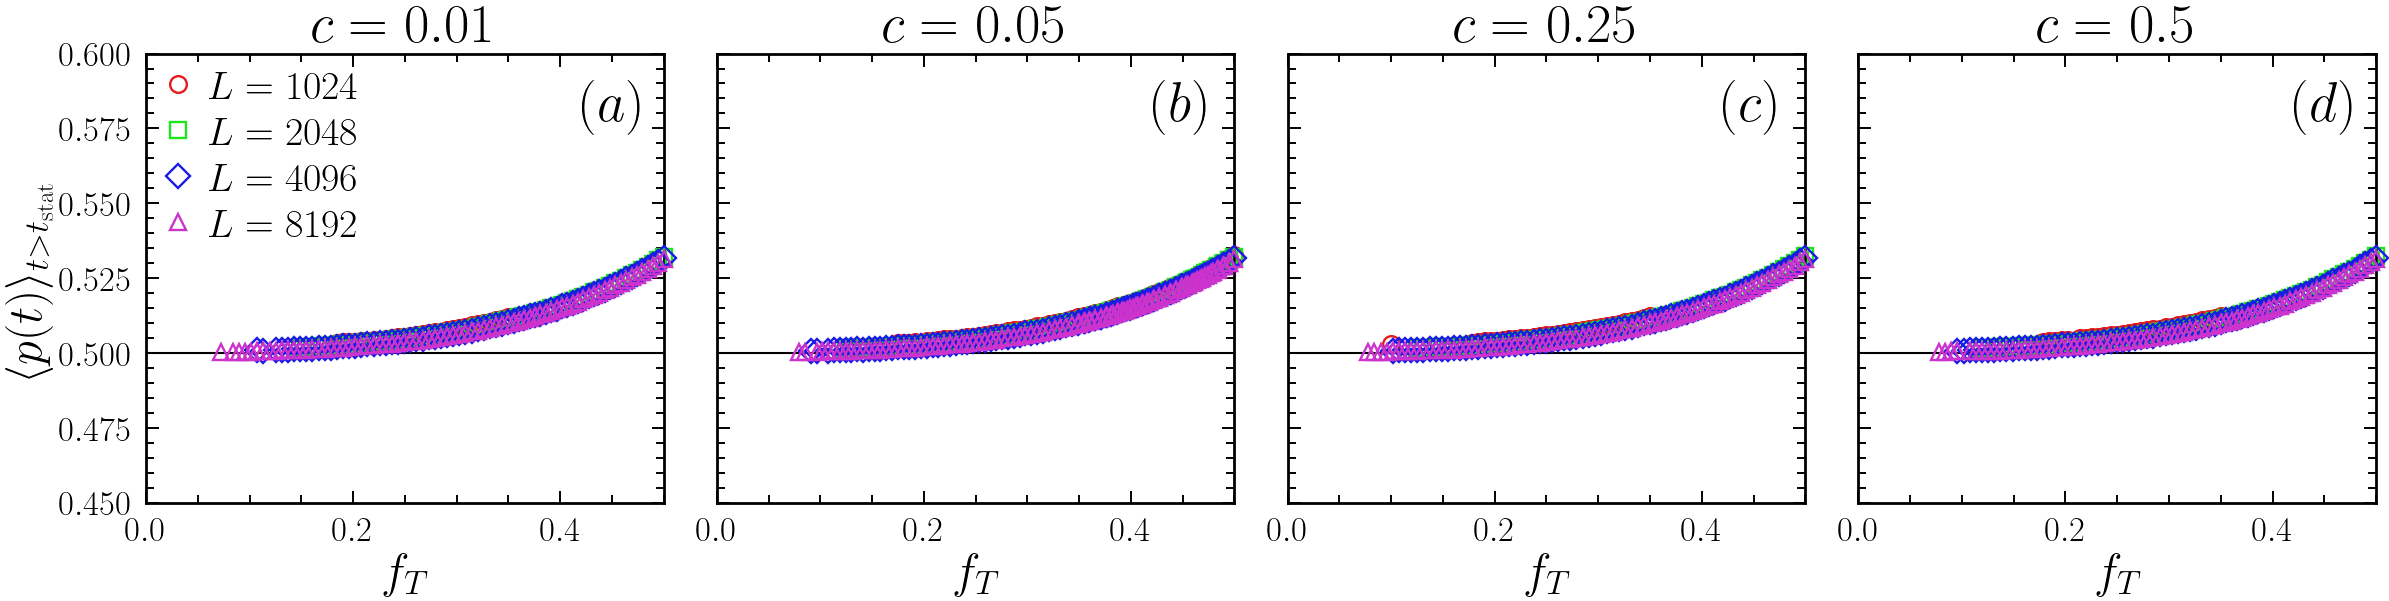

In [30]:
L_lst = [1024, 2048, 4096, 8192]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1]

p0 = 0.6
P0 = 0.1

base = 6

fig, axes = plt.subplots(
    len(nc_lst),
    len(c_lst),
    figsize=(len(c_lst)*base, len(nc_lst)*base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
    squeeze=False
)

markers = ['o', 's', 'D', '^']

mew = 1.7
pc = 0.5

fs_legend = 29
fs_title = 40
tick_label_size = 25
labels_size = 35
fs_labels_fig = 40
fs_l_fig = 35
ms = 12

labels_fig = [
    r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$',
    r'$(e)$', r'$(f)$', r'$(g)$', r'$(h)$',
    r'$(i)$', r'$(j)$', r'$(k)$', r'$(l)$',
    r'$(m)$', r'$(n)$', r'$(o)$', r'$(p)$'
]

f_TMAX = 0.50

for idx_nc, nc in enumerate(nc_lst):

    for idx_c, c in enumerate(c_lst):

        ax = axes[idx_nc, idx_c]

        y_max = 0.2

        for idx, L in enumerate(L_lst):

            rho = 1 / nc

            df_b = df[
                (df['nc'] == nc) &
                (df['L'] == L) &
                (df['c'] == c) &
                (df['type_perc'] == 'bond') &
                (df['p0'] == p0) &
                (df['P0'] == P0) &
                (df['order'] == 1) &
                (df['rho'] == rho) &
                (df['dim'] == 2)
            ].sort_values('f_T')

            df_b = df_b[df_b['f_T'] <= f_TMAX]

            if df_b.empty:
                continue

            f_t = df_b['f_T']
            pmean = df_b['p_mean']

            ax.plot(
                f_t,
                pmean,
                marker=markers[idx],
                ms=ms,
                mew=mew,
                ls='None',
                label=f'$L={L}$',
                zorder=10,
                clip_on=False
            )

            y_max = max(y_max, pmean.max())

        ax.axhline(pc, color='k', ls='solid')

        if idx_c == 0:
            # ax.text(
            #     0.04, 0.66,
            #     f'$n_c = {nc}$',
            #     transform=ax.transAxes,
            #     fontsize=fs_l_fig
            # )

            ax.set_ylabel(
                r'$\langle p(t) \rangle_{t>t_\mathrm{stat}}$',
                fontsize=labels_size
            )

            ax.legend(
                fontsize=fs_legend,
                loc='upper left',
                frameon=False
            )

        if idx_nc == 0:
            ax.set_title(f'$c={c}$', fontsize=fs_title)

        if idx_nc == len(nc_lst) - 1:
            ax.set_xlabel(r'$f_T$', fontsize=labels_size)

        ax.set_ylim(0.45, 0.6)
        ax.set_xlim(0, f_TMAX)

        ax.tick_params(
            axis='both',
            which='major',
            labelsize=tick_label_size,
            pad=10
        )

        ax.tick_params(
            axis='both',
            which='minor',
            labelsize=tick_label_size,
            pad=6
        )

for idx, ax_i in enumerate(axes.flatten()):

    if 0 <= idx <= 7:
        ax_i.text(
            0.84, 0.85,
            labels_fig[idx],
            transform=ax_i.transAxes,
            fontsize=fs_labels_fig
        )
    else:
        ax_i.text(
            0.84, 0.13,
            labels_fig[idx],
            transform=ax_i.transAxes,
            fontsize=fs_labels_fig
        )
dim = 2
plt.savefig(results_folder + f"fT_versus_pmean_dim_{dim}.pdf", dpi=300)
plt.show()

In [35]:
dim = 2
nc_lst = [1]

df_sub = df[
    (df["nc"].isin(nc_lst)) &
    (df["L"].isin(L_lst)) &
    (df["c"].isin(c_lst)) &
    (df["type_perc"] == "bond") &
    (df["p0"] == p0) &
    (df["P0"] == P0) &
    (df["dim"]==dim)
].copy()

# Evita problemas de comparação entre floats
df_sub["f_T_round"] = df_sub["f_T"].round(12)

# Mantém apenas os f_T que aparecem para todos os L
df_common = (
    df_sub
    .groupby(["nc", "c", "f_T_round"])["L"]
    .nunique()
    .reset_index(name="n_L")
)

df_common = df_common[df_common["n_L"] == len(L_lst)].copy()

# Constrói diretamente o DataFrame final em formato wide
rows = []

for (nc, c_val), g in df_common.groupby(["nc", "c"]):
    vals = np.sort(g["f_T_round"].dropna().unique())

    if len(vals) == 0:
        continue

    f_min = vals[0]
    f_max = vals[-1]

    # ponto médio do intervalo
    f_target = 0.5 * (f_min + f_max)

    # escolhe o f_T disponível mais próximo do ponto médio
    f_mid = vals[np.argmin(np.abs(vals - f_target))]

    rows.append({
        "nc": nc,
        "c": c_val,
        "f_T_min_common": f_min,
        "f_T_mid_common": f_mid,
        "f_T_max_common": f_max,
        "n_f_T_common": len(vals)
    })

df_ft_common = pd.DataFrame(rows)
df_ft_common
#df_ft_common.to_csv(f"../SOP_data/f_T_common.csv", index=False)


,nc,c,f_T_min_common,f_T_mid_common,f_T_max_common,n_f_T_common
0,1,0.01,0.184373,0.267186,0.35,29
1,1,0.05,0.174809,0.337404,0.50,58
2,1,0.25,0.178458,0.261271,0.35,30
3,1,0.50,0.178458,0.261271,0.35,29


In [37]:
c_target = 0.05
fT_lst = df_ft_common.loc[
    np.isclose(df_ft_common["c"], c_target),
    "f_T_min_common":"f_T_max_common"
].iloc[0].tolist()
fT_lst

[0.174809, 0.3374045, 0.5]

<>:181: SyntaxWarning: invalid escape sequence '\m'
<>:181: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4719/1442247067.py:181: SyntaxWarning: invalid escape sequence '\m'
  ax_pt.set_ylabel(f'$\\langle p(t) \\rangle_{{\mathrm{{samples}}}}$', fontsize=fs_label)


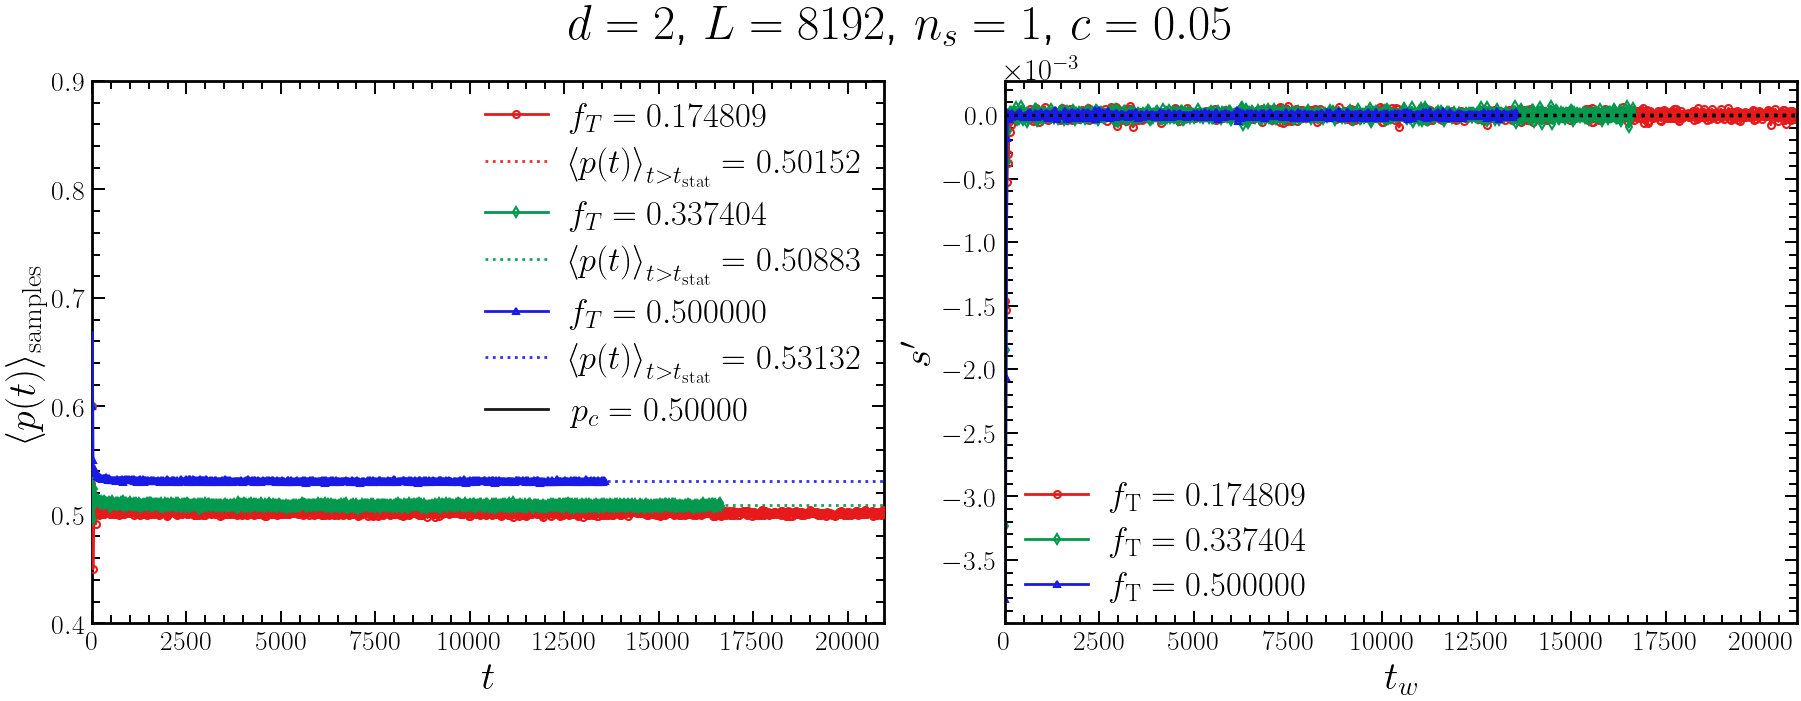

In [51]:
type_perc = 'bond'
ns = 1
dim = 2
L = 8192
c = 0.05
fT_lst = df_ft_common.loc[
    np.isclose(df_ft_common["c"], c),
    "f_T_min_common":"f_T_max_common"
].iloc[0].tolist()
vals

rho = 1 / ns

P0_target = 0.10
p0_target = 0.60

label_series = "p_all"   # ou "order_0"

markers = ['o-', 'd-', '^-']

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7),
    constrained_layout=True
)

ax_pt = axes[0]
ax_sp = axes[1]

t_max_pt = 0
t_max_sp = 0

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]
ms = 5
t_max = 0
fs_legend = 25
mew = 1.5
lw = 2.0
pc = 0.5
fs_label = 29
for idx, fT in enumerate(fT_lst):
    path = (
        f"../SOP_data/published/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/"
    )

    fn = "properties_mean_bundle.json"

    try:
        bundle = load_properties_bundle(path + fn)

        group = get_group_by_p0_P0(
            bundle,
            p0_target=p0_target,
            P0_target=P0_target
        )

        df_pt_all, results = analyze_pt_group(
            group,
            window_roll=15,
            window_block=20,
            y_key="pt_mean",
            use_rolling_for_blocks=True,
            center=True,
            drop_last=True,
        )

        df_pt = results[label_series]["df_pt"]
        df_s  = results[label_series]["df_s"]

        t_eq, pc_sop_mean = get_reference_from_group(
            group,
            label_series=label_series
        )

        # -----------------------------
        # Painel esquerdo: p(t)
        # -----------------------------
        t_pt = df_pt["t"].to_numpy()
        pt = df_pt["pt"].to_numpy()
        pt_roll = df_pt["pt_roll"].to_numpy()
        
        t_max = max(t_max, max(t_pt))
        t_max_pt = max(t_max_pt, np.max(t_pt))

        ax_pt.plot(
            t_pt,
            pt,
            markers[idx],
            color=colors[idx],
            markevery=25,
            lw=2.0,
            mew = mew,
            ms=ms,
            label=rf"$f_T = {fT:.6f}$",
            zorder=6,
            clip_on = True,
        )
        
        label_pt = rf"$f_{{\mathrm{{T}}}} = {fT:.6f}$"
        
        label_pc_sop = (
            rf"$\left\langle p(t)\right\rangle_"
            rf"{{t>t_{{\mathrm{{stat}}}}}} = {pc_sop_mean:.5f}$"
        )

        # Linha horizontal do pc tradicional
        label_pc = rf"$p_c = {pc:.5f}$"
        
        ax_pt.set_xlim(0, t_max)
        # ax_pt.axvline(
        #     t_eq,
        #     ls="--",
        #     lw=1.4,
        #     alpha=0.8,
        #     color=colors[idx]
        # )
        ax_pt.set_ylim(0.2, 0.5)
        if np.isfinite(pc_sop_mean):

            label_pc_sop = (
                rf"$\left\langle p(t)\right\rangle_"
                rf"{{t>t_{{\mathrm{{stat}}}}}} = {pc_sop_mean:.5f}$"
            )

            ax_pt.axhline(
                pc_sop_mean,
                ls=":",
                lw=lw,
                alpha=0.9,
                color=colors[idx],
                label=label_pc_sop
            )
        


        # -----------------------------
        # Painel direito: s'(t)
        # -----------------------------
        t_sp = df_s["t_s"].to_numpy()
        s_prime = df_s["s_prime"].to_numpy()

        t_max_sp = max(t_max_sp, np.max(t_sp))

        ax_sp.plot(
            t_sp,
            s_prime,
            markers[idx],
            color=colors[idx],
            lw=2.0,
            ms=ms,
            mew=mew,
            label=rf"$f_{{\mathrm{{T}}}} = {fT:.6f}$",
        )
        ax_sp.set_xlim(0, t_max)
        
        ax_sp.axhline(
            0,
            ls=":",
            lw=2.4,
            alpha=1.0,
            color='k'
        )
        leg_sp = ax_sp.legend(
            fontsize=fs_legend,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            labelspacing=0.4
        )

        for line in leg_sp.get_lines():
            line.set_linewidth(2.0)
        ax_sp.set_ylabel(f"$s'$",fontsize=fs_label)
        ax_pt.set_ylabel(f'$\\langle p(t) \\rangle_{{\mathrm{{samples}}}}$', fontsize=fs_label)

        
    except FileNotFoundError:
        print(f"Arquivo não encontrado para fT = {fT}")
        continue
from matplotlib.ticker import ScalarFormatter

formatter_sci = ScalarFormatter(useMathText=True)
formatter_sci.set_powerlimits((0, 0))

ax_sp.yaxis.set_major_formatter(formatter_sci)
ax_sp.yaxis.get_offset_text().set_fontsize(fs_label * 0.75)
ax_pt.set_xlabel(r"$t$", fontsize=fs_label)
ax_pt.set_xlabel(r"$t$", fontsize=fs_label)
ax_pt.set_ylim(0.4, 0.9)
ax_sp.set_xlabel(
    r"$t_w$",
    fontsize=fs_label
)
ax_pt.axhline(
    pc,
    ls="solid",
    lw=lw,
    alpha=0.9,
    color='k',
    label=f'$p_c = {pc:.5f}$'
)

leg_pt = ax_pt.legend(
    fontsize=fs_legend,
    handlelength=1.8,
    handletextpad=0.6,
    borderpad=0.4,
    labelspacing=0.4
)

for line in leg_pt.get_lines():
    line.set_linewidth(2.0)

fs_title = 35
fig.suptitle(f"$d = {dim}$, $L = {L}$, $n_s = {ns}$, $c = {c}$",fontsize=fs_title)
plt.savefig(results_folder + f"d_{dim}_ns_1_L_{L}.pdf",dpi=300)
plt.show()

## SURFACES

In [18]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fn = "/home/light/Documents/self_organization_percolation/SOP_data/raw/bond_percolation/num_colors_4/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_2.5000e-01/data_surfaces/light_seed_44_ts_20260422T133857_P0_0.10_p0_1.00.npz"
data = np.load(fn)

surface_pre = data["surface_preteq"]
surface_post = data["surface_posteq"]

x_pre, y_pre, z_pre, c_pre = surface_pre.T
x_post, y_post, z_post, c_post = surface_post.T

x_pre = x_pre.astype(int)
y_pre = y_pre.astype(int)
z_pre = z_pre.astype(float)
c_pre = c_pre.astype(int)

x_post = x_post.astype(int)
y_post = y_post.astype(int)
z_post = z_post.astype(float)
c_post = c_post.astype(int)

# --------------------------------------------------
# monta grid regular Z(y,x) e C(y,x)
# --------------------------------------------------
def build_surface_grid(x, y, z, c):
    nx = x.max() + 1
    ny = y.max() + 1

    Z = np.full((ny, nx), np.nan, dtype=float)
    C = np.full((ny, nx), np.nan, dtype=float)

    Z[y, x] = z
    C[y, x] = c

    return Z, C

Z_pre, C_pre = build_surface_grid(x_pre, y_pre, z_pre, c_pre)
Z_post, C_post = build_surface_grid(x_post, y_post, z_post, c_post)

# --------------------------------------------------
# cores discretas por espécie
# --------------------------------------------------
# 0 -> red, 1 -> blue, 2 -> green, 3 -> orange
species_colorscale = [
    [0.00, "red"],
    [0.249999, "red"],
    [0.25, "blue"],
    [0.499999, "blue"],
    [0.50, "green"],
    [0.749999, "green"],
    [0.75, "orange"],
    [1.00, "orange"],
]

def normalize_species(C):
    cmin = np.nanmin(C)
    cmax = np.nanmax(C)
    if cmax == cmin:
        return np.zeros_like(C, dtype=float)
    return (C - cmin) / (cmax - cmin)

C_pre_norm = normalize_species(C_pre)
C_post_norm = normalize_species(C_post)

# eixos
x_axis_pre = np.arange(Z_pre.shape[1])
y_axis_pre = np.arange(Z_pre.shape[0])

x_axis_post = np.arange(Z_post.shape[1])
y_axis_post = np.arange(Z_post.shape[0])

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=("Surface PRETEQ", "Surface POSTEQ"),
    horizontal_spacing=0.03
)

fig.add_trace(
    go.Surface(
        z=Z_pre,
        x=x_axis_pre,
        y=y_axis_pre,
        surfacecolor=C_pre_norm,
        colorscale=species_colorscale,
        cmin=0.0,
        cmax=1.0,
        showscale=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Surface(
        z=Z_post,
        x=x_axis_post,
        y=y_axis_post,
        surfacecolor=C_post_norm,
        colorscale=species_colorscale,
        cmin=0.0,
        cmax=1.0,
        showscale=False
    ),
    row=1, col=2
)

scene_common = dict(
    xaxis=dict(title="X"),
    yaxis=dict(title="Y"),
    zaxis=dict(title="Z"),
    aspectmode="cube"
)

fig.update_layout(
    width=1500,
    height=700,
    scene=scene_common,
    scene2=scene_common,
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/light/Documents/self_organization_percolation/SOP_data/raw/bond_percolation/num_colors_4/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_2.5000e-01/data_surfaces/light_seed_44_ts_20260422T133857_P0_0.10_p0_1.00.npz'

## NETWORK SURFACE 3D

In [5]:
path = "../network/3D_L256_nc4_rho0.2500_k1.0e-06_NT655/"
fn = "posteq_positions_nc4_L256.parquet"
df = pd.read_parquet(path + fn)
df

,x,y,z,color
0,154,91,46,10000221
1,155,91,46,10000222
2,156,91,46,10000223
3,154,92,46,10000222
4,116,186,46,20000247
...,...,...,...,...
2156492,240,195,254,20000974
2156493,150,77,255,10000982
2156494,49,88,255,30000904
2156495,169,157,255,40000961


In [ ]:
df_maxz = (
    df.groupby(["x", "y"], as_index=False)["z"]
      .max()
      .sort_values(["y", "x"])
)
Zmax = df.groupby(["y", "x"])["z"].max().unstack()
x_unique = Zmax.columns.to_numpy()
y_unique = Zmax.index.to_numpy()

X, Y = np.meshgrid(x_unique, y_unique)
Z = Zmax.to_numpy()

array([[226., 228., 228., ..., 226., 227., 226.],
       [226., 226., 228., ..., 225., 228., 223.],
       [226., 226., 227., ..., 226., 229., 226.],
       ...,
       [227., 230., 229., ..., 231., 231., 213.],
       [227., 227., 229., ..., 231., 231., 226.],
       [227., 227., 227., ..., 230., 231., 226.]])

In [17]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# maior z para cada par (x,y)
Zmax = df.groupby(["y", "x"])["z"].max().unstack()

# malha
x_unique = Zmax.columns.to_numpy()
y_unique = Zmax.index.to_numpy()
X, Y = np.meshgrid(x_unique, y_unique)
Z = Zmax.to_numpy()

# gráfico interativo
fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z
        )
    ]
)

fig.update_layout(
    title="Malha 3D com z máximo para cada (x,y)",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
    ),
    width=800,
    height=700,
)

fig.show()

In [5]:
import json
import numpy as np
import plotly.graph_objects as go

fn = "../SOP_data/raw/bond_percolation/num_colors_4/dim_3/L_256/fT_constant/fT_1.000000e-02/c_1.000000e-01/rho_2.5000e-01/data_surfaces/light_seed_44_ts_20260504T130458_P0_0.10_p0_1.00.json"

with open(fn, "r") as f:
    data = json.load(f)

surface = np.asarray(data["surface_posteq"])

x, y, z, c = surface.T
x = x.astype(int)
y = y.astype(int)
z = z.astype(float)

Z = np.full((y.max() + 1, x.max() + 1), np.nan)
Z[y, x] = z

x_axis = np.arange(Z.shape[1])
y_axis = np.arange(Z.shape[0])

fig = go.Figure(
    data=[
        go.Surface(
            x=x_axis,
            y=y_axis,
            z=Z,
        )
    ]
)

fig.update_layout(
    title="Surface POSTEQ",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
    ),
    width=800,
    height=700,
)

fig.show()


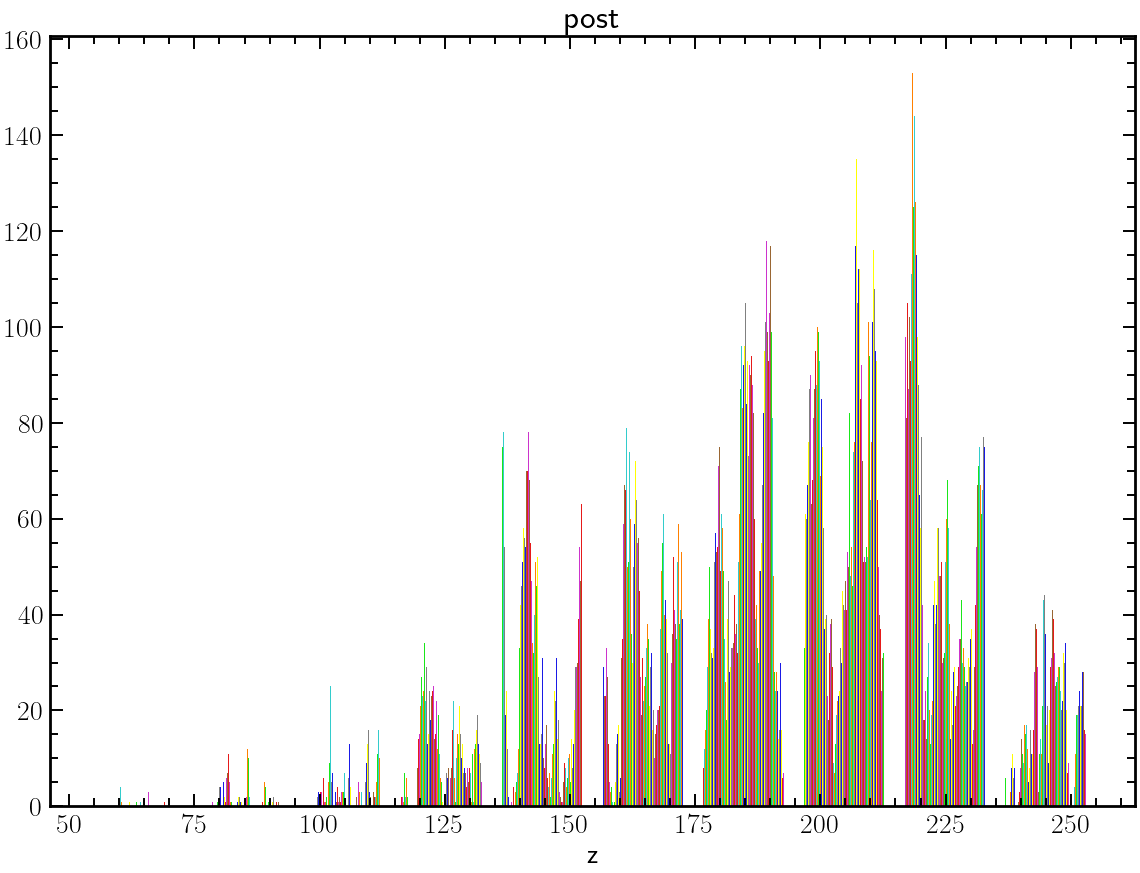

In [14]:
plt.hist(Z)
plt.xlabel('z')
plt.title("post")
plt.show()

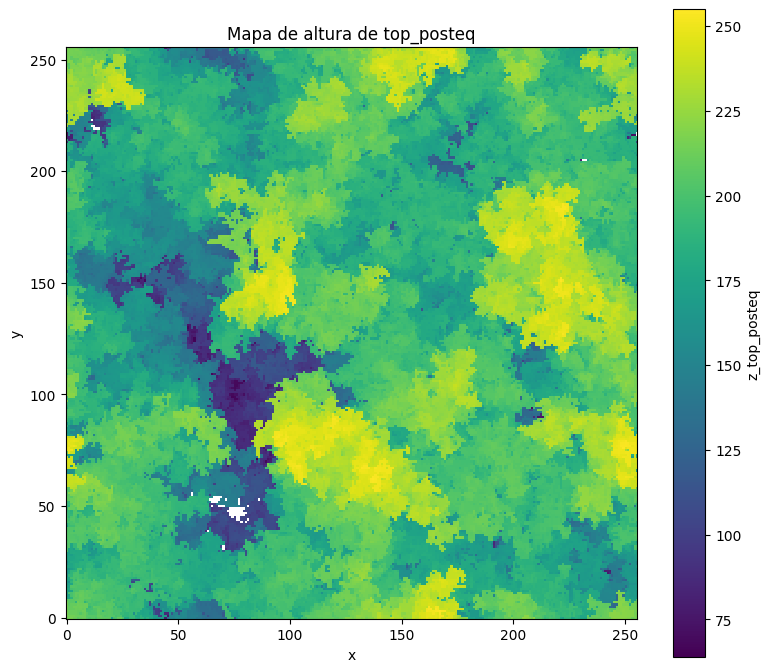

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fn = "/home/light/Documents/self_organization_percolation/SOP_data/raw/bond_percolation/num_colors_4/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_2.5000e-01/data_surfaces/light_seed_11_ts_20260422T124831_P0_0.10_p0_1.00.npz"
data = np.load(fn)

top_post = data["top_posteq"]
x, y, z, c = top_post.T
x = x.astype(int)
y = y.astype(int)
z = z.astype(int)

Lx = x.max() + 1
Ly = y.max() + 1

H = np.full((Ly, Lx), np.nan)
H[y, x] = z

plt.figure(figsize=(8, 7))
im = plt.imshow(H, origin="lower", cmap="viridis", interpolation="nearest")
plt.colorbar(im, label="z_top_posteq")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapa de altura de top_posteq")
plt.tight_layout()
plt.show()

(array([  192.,  1295.,  1390.,  1777.,  3780.,  8249., 18818., 15582.,
         9453.,  4926.]),
 array([ 64. ,  83.1, 102.2, 121.3, 140.4, 159.5, 178.6, 197.7, 216.8,
        235.9, 255. ]),
 <BarContainer object of 10 artists>)

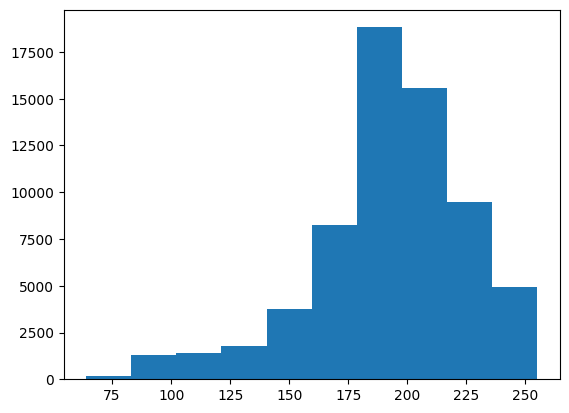

In [14]:
plt.hist(z)

In [6]:
import numpy as np
L = 256
def ler_rede_npz(caminho, reconstruir_rede=False, retornar_coords=False):
    """
    Lê um arquivo .npz de rede esparsa.

    Parâmetros
    ----------
    caminho : str
        Caminho do arquivo .npz
    reconstruir_rede : bool, opcional
        Se True, reconstrói a rede densa completa.
    retornar_coords : bool, opcional
        Se True, também retorna as coordenadas (x,y,z,...) dos índices ativos.

    Retorna
    -------
    dict
        Dicionário com metadados e arrays lidos do arquivo.
    """
    with np.load(caminho, allow_pickle=False) as arq:
        dim = int(arq["dim"])
        num_colors = int(arq["num_colors"])
        seed = int(arq["seed"])
        shape = tuple(int(x) for x in arq["shape"])
        rho = arq["rho"].astype(float, copy=False)
        active_idx = arq["active_idx"].astype(np.int64, copy=False)
        active_val = arq["active_val"].astype(np.int32, copy=False)

    out = {
        "dim": dim,
        "num_colors": num_colors,
        "seed": seed,
        "shape": shape,
        "rho": rho,
        "active_idx": active_idx,
        "active_val": active_val,
        "num_active": len(active_idx),
    }

    if retornar_coords:
        coords = np.column_stack(np.unravel_index(active_idx, shape))
        out["coords"] = coords

    if reconstruir_rede:
        rede = np.zeros(shape, dtype=active_val.dtype)
        rede.flat[active_idx] = active_val
        out["rede"] = rede

    return out
path = "/home/light/Documents/self_organization_percolation/SOP_data/raw/bond_percolation_equilibration/num_colors_8/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_1.2500e-01/network/"
fn = path + "light_seed_7978782_ts_20260420T143749_P0_0.10_p0_1.00.npz"
dados = ler_rede_npz(fn, reconstruir_rede=False, retornar_coords=True)

print("dim =", dados["dim"])
print("num_colors =", dados["num_colors"])
print("seed =", dados["seed"])
print("shape =", dados["shape"])
print("rho =", dados["rho"])
print("num_active =", dados["num_active"])
print("num_total =", L**3)
print("fraction_active = ", dados["num_active"]/L**3)
print("primeiros índices ativos =", dados["active_idx"][:10])
print("primeiros valores ativos =", dados["active_val"][:10])
print("primeiras coordenadas =", dados["coords"][:10])


dim = 3
num_colors = 8
seed = -1
shape = (256, 256, 256)
rho = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
num_active = 9390294
num_total = 16777216
fraction_active =  0.5597051382064819
primeiros índices ativos = [0 1 2 3 4 5 6 7 8 9]
primeiros valores ativos = [10000000 10000001 10000002 10000001 10000000 10000001 10000002 10000003
 50000003 50000002]
primeiras coordenadas = [[0 0 0]
 [0 0 1]
 [0 0 2]
 [0 0 3]
 [0 0 4]
 [0 0 5]
 [0 0 6]
 [0 0 7]
 [0 0 8]
 [0 0 9]]


In [3]:
import numpy as np

def ler_arquivo_npz(caminho, reconstruir_rede=False):
    """
    Lê um arquivo .npz de rede salva em formato esparso.

    Parâmetros
    ----------
    caminho : str
        Caminho do arquivo .npz
    reconstruir_rede : bool
        Se True, reconstrói a rede densa completa.

    Retorna
    -------
    dict
        Dicionário com os dados lidos.
    """
    with np.load(caminho, allow_pickle=False) as arq:
        dados = {chave: arq[chave] for chave in arq.files}

    out = {
        "dim": int(dados["dim"]),
        "num_colors": int(dados["num_colors"]),
        "seed": int(dados["seed"]),
        "shape": tuple(dados["shape"]),
        "rho": dados["rho"],
        "active_idx": dados["active_idx"],
        "active_val": dados["active_val"],
    }

    if reconstruir_rede:
        rede = np.zeros(out["shape"], dtype=out["active_val"].dtype)
        rede.flat[out["active_idx"]] = out["active_val"]
        out["rede"] = rede

    return out

In [5]:
dados = ler_arquivo_npz(fn, reconstruir_rede=True)

print("dim =", dados["dim"])
print("shape =", dados["shape"])
print("seed =", dados["seed"])
print("rho =", dados["rho"])
print("primeiros índices =", dados["active_idx"][:10])
print("primeiros valores =", dados["active_val"][:10])
print("unique da rede =", np.unique(dados["rede"]))

dim = 3
shape = (np.int32(256), np.int32(256), np.int32(256))
seed = -1
rho = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
primeiros índices = [0 1 2 3 4 5 6 7 8 9]
primeiros valores = [10000000 10000001 10000002 10000001 10000000 10000001 10000002 10000003
 50000003 50000002]
unique da rede = [       0 10000000 10000001 ... 80000633 80000634 80000635]
